# MOXIE-VASA — Pipeline Demo

**Project:** MOXIE-VASA (Video Analysis for Stress Assessment)  
**Author:** Durvi Bhati  
**Version:** Phase 1 — Personal Video Pipeline  

---

This notebook demonstrates the full MOXIE-VASA processing pipeline on a single personal video (`mine_4.mp4`).  
It runs each stage in sequence — preprocessing, OpenFace facial feature extraction, and custom rPPG analysis — and visualises the key outputs.

### What this notebook covers

| Stage | Module | Output |
|---|---|---|
| 1. Preprocessing | `preprocessing.py` | Codec-normalised `_safe.mp4` + video metadata |
| 2. Facial Analysis | `openface/video_engine.py` | Action Unit CSV (AU01–AU45, pose, gaze, 68 landmarks) |
| 3. rPPG Analysis | `rppg/pipeline.py` | BVP waveform, HR/HRV metrics JSON |
| 4. Visualisation | — | OpenFace CSV preview, BVP waveform plot, HR timeline |

### Prerequisites

- Docker Desktop running with `algebr/openface:latest` image pulled
- `config.yaml` set up at the project root (copy from `config.template.yaml`)
- `mine_4.mp4` present in `moxie_data/My_video/`
- Dependencies installed: `opencv-python numpy scipy pandas pyyaml matplotlib`
---

In [24]:
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Hardcode the project root — avoids WSL cwd issues
PROJECT_ROOT = Path("/mnt/c/Users/durvi/University of Michigan Dropbox/Durvi Bhati/moxie_vas_tool/MOXIE-VASA-Tool")
MOXIE_SRC   = PROJECT_ROOT / 'src' / 'Moxie'

if str(MOXIE_SRC) not in sys.path:
    sys.path.insert(0, str(MOXIE_SRC))

# Also set working directory so relative paths in modules work correctly
os.chdir(MOXIE_SRC)

print(f'Project root : {PROJECT_ROOT}')
print(f'Moxie src    : {MOXIE_SRC}')
print(f'Path exists  : {MOXIE_SRC.exists()}')

Project root : /mnt/c/Users/durvi/University of Michigan Dropbox/Durvi Bhati/moxie_vas_tool/MOXIE-VASA-Tool
Moxie src    : /mnt/c/Users/durvi/University of Michigan Dropbox/Durvi Bhati/moxie_vas_tool/MOXIE-VASA-Tool/src/Moxie
Path exists  : True


In [25]:
from data_ingestion import load_config

# Load config.yaml from project root
cfg = load_config(PROJECT_ROOT / 'config.yaml')

# ── Resolve key paths ─────────────────────────────────────────────────────────
PERSONAL_VIDEOS_DIR = Path(cfg['paths']['personal_videos'])
OPENFACE_OUTPUT_DIR = Path(cfg['paths']['openface_output'])
RPPG_OUTPUT_DIR     = Path(cfg['paths']['rppg_output'])

# ── Demo video ────────────────────────────────────────────────────────────────
DEMO_VIDEO_NAME = 'mine_4.mp4'
DEMO_VIDEO_PATH = PERSONAL_VIDEOS_DIR / DEMO_VIDEO_NAME

print(f'Demo video   : {DEMO_VIDEO_PATH}')
print(f'Video exists : {DEMO_VIDEO_PATH.exists()}')
print(f'OpenFace out : {OPENFACE_OUTPUT_DIR}')
print(f'rPPG out     : {RPPG_OUTPUT_DIR}')

Demo video   : /mnt/c/Users/durvi/University of Michigan Dropbox/Durvi Bhati/moxie_vas_tool/MOXIE-VASA-Tool/moxie_data/My_video/mine_4.mp4
Video exists : True
OpenFace out : Pipeline_Output/result_openface
rPPG out     : Pipeline_Output/result_rppg


## 1. Preprocessing

`preprocessing.py` standardises every input video to a codec-safe H.264 MP4 before any analysis begins.

**What it does:**
- Transcodes to H.264 at CRF 15 (near-lossless — preserves skin colour values rPPG depends on)
- Reads and corrects rotation metadata using `ffprobe`
- Runs a quick Haar cascade face presence check on 10 sampled frames
- Returns the safe video path **and** a metadata dict containing the actual FPS

The actual FPS matters — at ~29.7 fps the Butterworth bandpass filter needs different coefficients than at exactly 30 fps. This is why FPS is always read from the file, never hardcoded.
from preprocessing import route_and_preprocess

In [26]:
import sys
import cv2
from pathlib import Path

MOXIE_SRC = Path().resolve().parent / 'src' / 'Moxie'
if str(MOXIE_SRC) not in sys.path:
    sys.path.insert(0, str(MOXIE_SRC))

from preprocessing import route_and_preprocess

SAFE_VIDEO_PATH = PERSONAL_VIDEOS_DIR / 'mine_4_safe.mp4'

if SAFE_VIDEO_PATH.exists():
    print(f'[Preprocessing] Safe copy already exists — skipping transcode.')
    print(f'  Path: {SAFE_VIDEO_PATH}')
    cap = cv2.VideoCapture(str(SAFE_VIDEO_PATH), cv2.CAP_FFMPEG)
    metadata = {
        'fps':         cap.get(cv2.CAP_PROP_FPS),
        'width':       int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        'height':      int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        'frame_count': int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        'rotation':    0,
    }
    cap.release()
    safe_path = str(SAFE_VIDEO_PATH)
else:
    print(f'[Preprocessing] Running on {DEMO_VIDEO_NAME} ...')
    safe_path, metadata = route_and_preprocess(str(DEMO_VIDEO_PATH))

fps = metadata['fps']
duration_s = metadata['frame_count'] / fps

print(f'\nVideo metadata:')
print(f"  Resolution : {metadata['width']} x {metadata['height']}")
print(f"  FPS        : {fps:.3f}")
print(f"  Frames     : {metadata['frame_count']}")
print(f"  Duration   : {duration_s:.1f} seconds ({duration_s/60:.1f} minutes)")
print(f"  Rotation   : {metadata['rotation']}\u00b0")
print(f"  Safe path  : {safe_path}")


[Preprocessing] Safe copy already exists — skipping transcode.
  Path: /mnt/c/Users/durvi/University of Michigan Dropbox/Durvi Bhati/moxie_vas_tool/MOXIE-VASA-Tool/moxie_data/My_video/mine_4_safe.mp4

Video metadata:
  Resolution : 1920 x 1080
  FPS        : 29.797
  Frames     : 4561
  Duration   : 153.1 seconds (2.6 minutes)
  Rotation   : 0°
  Safe path  : /mnt/c/Users/durvi/University of Michigan Dropbox/Durvi Bhati/moxie_vas_tool/MOXIE-VASA-Tool/moxie_data/My_video/mine_4_safe.mp4


##  OpenFace — Facial Feature Extraction

`openface/video_engine.py` runs the OpenFace `FeatureExtraction` binary inside a Docker container.  
It mounts the video folder at `/in/` and the output folder at `/out/` inside the container.

**Extracted features per frame:**
- **Action Units (AU01–AU45):** Intensity (`_r`, 0–5 scale) and presence (`_c`, 0/1) for 17 stress-relevant AUs
- **Head pose:** Rotation (Rx, Ry, Rz) and translation (Tx, Ty, Tz)
- **Gaze:** Horizontal and vertical gaze angles
- **Landmarks:** 68 2D and 3D facial landmark coordinates — reused by the rPPG module for ROI localization

> **Note:** OpenFace runs inside Docker — make sure Docker Desktop is running before executing this cell.

In [15]:
import sys
from pathlib import Path

# Ensure src/Moxie is on path (safe to call multiple times)
MOXIE_SRC = Path().resolve().parent / 'src' / 'Moxie'
if str(MOXIE_SRC) not in sys.path:
    sys.path.insert(0, str(MOXIE_SRC))

from openface.video_engine import run_openface_feature_extraction

OPENFACE_CSV = OPENFACE_OUTPUT_DIR / 'mine_4_safe.csv'

if OPENFACE_CSV.exists() and OPENFACE_CSV.stat().st_size > 0:
    print(f'[OpenFace] Output CSV already exists — skipping Docker run.')
    print(f'  Path: {OPENFACE_CSV}')
    openface_success = True
else:
    print(f'[OpenFace] Running Docker container on {Path(safe_path).name} ...')
    print('  (This takes 5-10 minutes for a 2-minute video — progress streams below)')
    openface_success = run_openface_feature_extraction(
        safe_path,
        str(OPENFACE_OUTPUT_DIR)
    )

print(f'\nOpenFace success: {openface_success}')
if openface_success:
    size_kb = OPENFACE_CSV.stat().st_size / 1024
    print(f'CSV size: {size_kb:.0f} KB')


[OpenFace] Running Docker container on mine_4_safe.mp4 ...
  (This takes 5-10 minutes for a 2-minute video — progress streams below)
[VideoEngine] Input  : mine_4_safe.mp4  (ext=.mp4)
[VideoEngine] Output : /mnt/c/Users/durvi/University of Michigan Dropbox/Durvi Bhati/moxie_vas_tool/MOXIE-VASA-Tool/tutorials/Pipeline_Output/result_openface
[VideoEngine] Spinning up Docker container...
[VideoEngine] Command: docker run --rm --platform linux/amd64 --entrypoint /home/openface-build/build/bin/FeatureExtraction -w /home/openface-build/build/bin -v /mnt/c/Users/durvi/University of Michigan Dropbox/Durvi Bhati/moxie_vas_tool/MOXIE-VASA-Tool/moxie_data/My_video:/in -v /mnt/c/Users/durvi/University of Michigan Dropbox/Durvi Bhati/moxie_vas_tool/MOXIE-VASA-Tool/tutorials/Pipeline_Output/result_openface:/out algebr/openface:latest -f /in/mine_4_safe.mp4 -out_dir /out -aus -pose -gaze -2Dfp -3Dfp -simalign
  [OpenFace] libdc1394 error: Failed to initialize libdc1394
  [OpenFace] Could not find the

### OpenFace CSV Preview

The CSV contains one row per video frame. Let's look at the structure and the stress-relevant AU columns.

In [16]:
# Load the OpenFace CSV — strip leading spaces from all column names

df_of = pd.read_csv(OPENFACE_CSV)
df_of.columns = [c.strip() for c in df_of.columns]

print(f'Shape: {df_of.shape[0]} frames × {df_of.shape[1]} columns')
print(f'Duration covered: {df_of.shape[0] / fps:.1f} seconds')
print(f'\nColumn groups:')
print(f'  Frame/meta  : frame, face_id, timestamp, confidence, success')
print(f'  Gaze        : {len([c for c in df_of.columns if "gaze" in c])} columns')
print(f'  Landmarks   : {len([c for c in df_of.columns if c.startswith("x_") or c.startswith("y_")])} columns (68×2D)')
print(f'  Action Units: {len([c for c in df_of.columns if c.startswith("AU")])} columns')
print(f'  Pose        : {len([c for c in df_of.columns if "pose" in c])} columns')

Shape: 4561 frames × 674 columns
Duration covered: 153.1 seconds

Column groups:
  Frame/meta  : frame, face_id, timestamp, confidence, success
  Gaze        : 8 columns
  Landmarks   : 136 columns (68×2D)
  Action Units: 35 columns
  Pose        : 6 columns


In [17]:
# Show the stress-relevant AU intensity columns
au_intensity_cols = [c for c in df_of.columns if c.endswith('_r') and c.startswith('AU')]
au_intensity_cols = sorted(au_intensity_cols)

print('AU intensity columns (first 5 rows):')
display(df_of[['frame', 'timestamp', 'confidence'] + au_intensity_cols[:8]].head())

print(f'\nMean AU intensities across all frames:')
au_means = df_of[au_intensity_cols].mean().sort_values(ascending=False)
display(au_means.round(4).to_frame('mean_intensity').head(10))

AU intensity columns (first 5 rows):


,frame,timestamp,confidence,AU01_r,AU02_r,AU04_r,AU05_r,AU06_r,AU07_r,AU09_r,AU10_r
0,1,0.000,0.98,0.92,0.20,0.08,0.0,0.0,0.0,0.0,0.0
1,2,0.034,0.98,0.97,0.07,0.03,0.0,0.0,0.0,0.0,0.0
2,3,0.067,0.98,1.01,0.00,0.00,0.0,0.0,0.0,0.0,0.0
3,4,0.101,0.98,0.96,0.00,0.00,0.0,0.0,0.0,0.0,0.0
4,5,0.134,0.98,0.86,0.00,0.00,0.0,0.0,0.0,0.0,0.0



Mean AU intensities across all frames:


,mean_intensity
AU25_r,1.0310
AU14_r,0.8132
AU45_r,0.6206
AU17_r,0.5852
AU12_r,0.5674
AU26_r,0.4318
AU01_r,0.3345
AU15_r,0.2093
AU23_r,0.2005
AU20_r,0.1912


In [18]:
###  Detection confidence

# OpenFace reports a per-frame confidence score (0–1). Frames below 0.5 are marked as failed detections and excluded from rPPG ROI extraction.

confidence = df_of['confidence']
success    = df_of['success']

print(f'Confidence stats:')
print(f'  Mean   : {confidence.mean():.3f}')
print(f'  Min    : {confidence.min():.3f}')
print(f'  Frames with success=1 : {success.sum()} / {len(success)} ({100*success.mean():.1f}%)')

Confidence stats:
  Mean   : 0.971
  Min    : 0.930
  Frames with success=1 : 4561 / 4561 (100.0%)


##  rPPG Analysis

`rppg/pipeline.py` orchestrates the full remote photoplethysmography chain:

```
OpenFace landmarks → ROI bounding boxes (forehead, cheeks, glabella)
    → mean RGB per ROI per frame
    → area-weighted combination across ROIs
    → detrending (remove slow illumination drift)
    → Butterworth bandpass filter (0.7–3.0 Hz)
    → POS algorithm (Wang et al. 2017) → BVP waveform
    → peak detection → HR, SDNN, RMSSD, LF/HF ratio
```

**Why OpenFace landmarks for ROI localization?**  
Using the 68 2D landmarks from the OpenFace CSV means face detection runs exactly once the same landmark positions drive both the AU analysis and the rPPG ROI extraction. This is more efficient and more accurate than running a second face detector.

---

In [27]:
import sys
from pathlib import Path

MOXIE_SRC = Path().resolve().parent / 'src' / 'Moxie'
if str(MOXIE_SRC) not in sys.path:
    sys.path.insert(0, str(MOXIE_SRC))

from rppg.pipeline import run_rppg_analysis

BVP_CSV      = RPPG_OUTPUT_DIR / 'mine_4_safe_bvp.csv'
METRICS_JSON = RPPG_OUTPUT_DIR / 'mine_4_safe_metrics.json'

if BVP_CSV.exists() and METRICS_JSON.exists():
    print('[rPPG] Outputs already exist — skipping pipeline run.')
    print(f'  BVP CSV      : {BVP_CSV}')
    print(f'  Metrics JSON : {METRICS_JSON}')
    rppg_success = True
else:
    print('[rPPG] Running rPPG analysis...')
    rppg_success = run_rppg_analysis(
        video_path       = safe_path,
        output_dir       = str(RPPG_OUTPUT_DIR),
        ground_truth_bvp = None,
        fps              = fps,
    )

print(f'\nrPPG success: {rppg_success}')


[rPPG] Outputs already exist — skipping pipeline run.
  BVP CSV      : Pipeline_Output/result_rppg/mine_4_safe_bvp.csv
  Metrics JSON : Pipeline_Output/result_rppg/mine_4_safe_metrics.json

rPPG success: True


In [28]:
with open(METRICS_JSON) as f:
    metrics = json.load(f)

hr = metrics['hr']

print('=' * 45)
print('  rPPG Metrics — mine_4.mp4')
print('=' * 45)
print(f"  Video duration   : {hr['duration_seconds']} seconds")
print(f"  Beats detected   : {hr['n_beats_detected']}")
print()
print('  Heart Rate')
print(f"    Mean HR        : {hr['hr_mean']} bpm")
print(f"    HR std         : {hr['hr_std']} bpm")
print()
print('  Heart Rate Variability (HRV)')
print(f"    SDNN           : {hr['sdnn']} ms")
print(f"    RMSSD          : {hr['rmssd']} ms")
print(f"    LF power       : {hr['lf_power']}")
print(f"    HF power       : {hr['hf_power']}")
print(f"    LF/HF ratio    : {hr['lf_hf_ratio']}")

if hr.get('warnings'):
    print()
    print('  Warnings:')
    for w in hr['warnings']:
        print(f'     {w}')

  rPPG Metrics — mine_4.mp4
  Video duration   : 153.07 seconds
  Beats detected   : 104

  Heart Rate
    Mean HR        : 71.87 bpm
    HR std         : 28.39 bpm

  Heart Rate Variability (HRV)
    SDNN           : 273.39 ms
    RMSSD          : 340.02 ms
    LF power       : 16234.2983
    HF power       : 32062.3024
    LF/HF ratio    : 0.5063


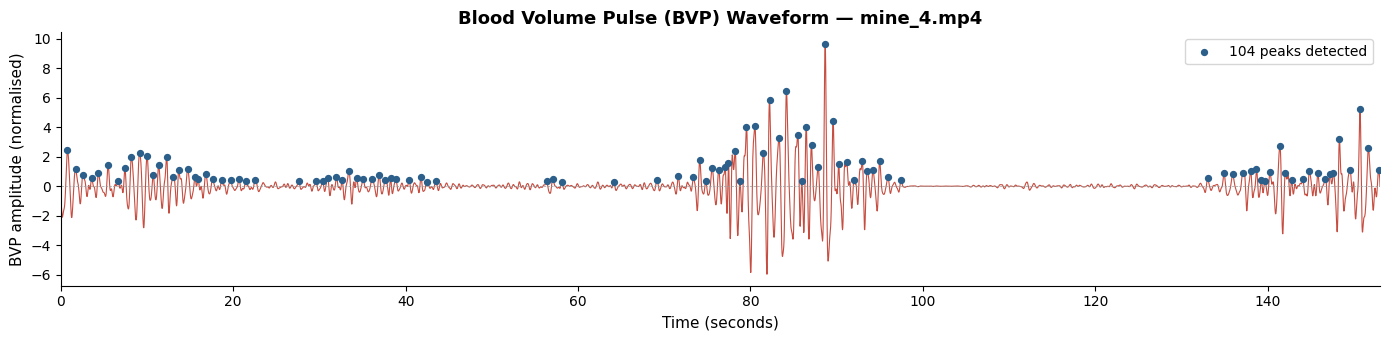

Saved to Pipeline_Output/result_rppg/mine_4_bvp_plot.png


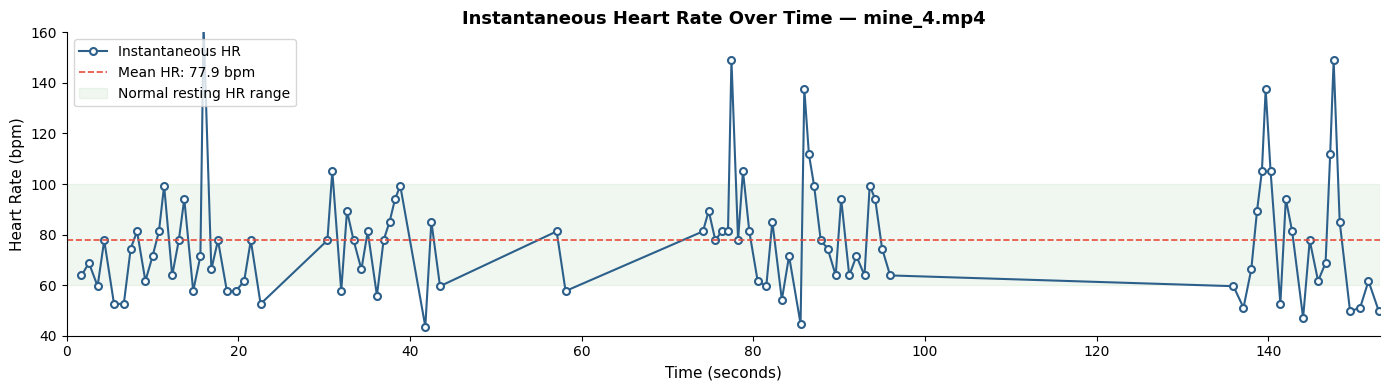

Saved to Pipeline_Output/result_rppg/mine_4_hr_plot.png


,File,Description,Size,Status
0,mine_4_safe.mp4,Preprocessed video (H.264 CRF 15),295765 KB,✅
1,mine_4_safe.csv,"OpenFace features (AUs, pose, gaze, 68 landmarks)",20417 KB,✅
2,mine_4_safe_bvp.csv,BVP waveform (one value per valid frame),90 KB,✅
3,mine_4_safe_rgb.csv,"Per-ROI RGB signals (forehead, cheeks, glabella)",497 KB,✅
4,mine_4_safe_metrics.json,"HR/HRV metrics (HR, SDNN, RMSSD, LF/HF)",0 KB,✅



Pipeline complete for mine_4.mp4
  Mean HR  : 71.87 bpm
  SDNN     : 273.39 ms
  RMSSD    : 340.02 ms
  LF/HF    : 0.5063


In [30]:
## 4. Visualisations

### BVP Waveform

#The BVP (Blood Volume Pulse) waveform is the raw output of the POS algorithm 
# a normalised signal where each peak corresponds to one heartbeat. Clean peaks with consistent spacing indicate good signal quality.

df_bvp = pd.read_csv(BVP_CSV)
bvp    = df_bvp['bvp'].values

# Build time axis — BVP has one sample per valid frame
time_bvp = np.arange(len(bvp)) / fps

fig, ax = plt.subplots(figsize=(14, 3.5))

ax.plot(time_bvp, bvp, color='#C0392B', linewidth=0.8, alpha=0.9)
ax.axhline(0, color='#999999', linewidth=0.5, linestyle='--')

ax.set_xlabel('Time (seconds)', fontsize=11)
ax.set_ylabel('BVP amplitude (normalised)', fontsize=11)
ax.set_title('Blood Volume Pulse (BVP) Waveform — mine_4.mp4', fontsize=13, fontweight='bold')
ax.set_xlim(0, time_bvp[-1])

# Annotate peak count
from scipy.signal import find_peaks
peaks, _ = find_peaks(bvp, distance=int(fps*0.4), height=bvp.mean() + bvp.std()*0.3)
ax.scatter(time_bvp[peaks], bvp[peaks], color='#2C5F8A', s=18, zorder=5, label=f'{len(peaks)} peaks detected')
ax.legend(fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(RPPG_OUTPUT_DIR / 'mine_4_bvp_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {RPPG_OUTPUT_DIR}/mine_4_bvp_plot.png')

### Instantaneous Heart Rate Over Time

# By computing the time between consecutive BVP peaks (RR intervals), we can track how heart rate changes across the video. 
# A resting HR typically sits between 60–100 bpm; stress responses often push it above 85 bpm.

if len(peaks) >= 4:
    rr_frames   = np.diff(peaks)
    rr_ms       = (rr_frames / fps) * 1000
    hr_per_beat = 60000 / rr_ms

    # Filter physiologically implausible values
    valid = (hr_per_beat > 40) & (hr_per_beat < 200)
    hr_valid   = hr_per_beat[valid]
    time_beats = time_bvp[peaks[1:]][valid]

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(time_beats, hr_valid, color='#2C5F8A', linewidth=1.5,
            marker='o', markersize=5, markerfacecolor='white',
            markeredgecolor='#2C5F8A', markeredgewidth=1.5, label='Instantaneous HR')

    mean_hr = hr_valid.mean()
    ax.axhline(mean_hr, color='#E74C3C', linewidth=1.2, linestyle='--',
               label=f'Mean HR: {mean_hr:.1f} bpm')
    ax.axhspan(60, 100, alpha=0.06, color='green', label='Normal resting HR range')

    ax.set_xlabel('Time (seconds)', fontsize=11)
    ax.set_ylabel('Heart Rate (bpm)', fontsize=11)
    ax.set_title('Instantaneous Heart Rate Over Time — mine_4.mp4', fontsize=13, fontweight='bold')
    ax.set_xlim(0, time_bvp[-1])
    ax.set_ylim(40, 160)
    ax.legend(fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(RPPG_OUTPUT_DIR / 'mine_4_hr_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {RPPG_OUTPUT_DIR}/mine_4_hr_plot.png')
else:
    print('Too few peaks detected for HR timeline plot.')

## 5. Summary

#The table below summarises all outputs produced by the MOXIE-VASA pipeline for this video.

output_files = [
    ('mine_4_safe.mp4',          PERSONAL_VIDEOS_DIR,  'Preprocessed video (H.264 CRF 15)'),
    ('mine_4_safe.csv',          OPENFACE_OUTPUT_DIR,  'OpenFace features (AUs, pose, gaze, 68 landmarks)'),
    ('mine_4_safe_bvp.csv',      RPPG_OUTPUT_DIR,      'BVP waveform (one value per valid frame)'),
    ('mine_4_safe_rgb.csv',      RPPG_OUTPUT_DIR,      'Per-ROI RGB signals (forehead, cheeks, glabella)'),
    ('mine_4_safe_metrics.json', RPPG_OUTPUT_DIR,      'HR/HRV metrics (HR, SDNN, RMSSD, LF/HF)'),
]

rows = []
for fname, folder, desc in output_files:
    fpath = folder / fname
    exists = fpath.exists()
    size   = f'{fpath.stat().st_size / 1024:.0f} KB' if exists else '—'
    rows.append({'File': fname, 'Description': desc, 'Size': size, 'Status': '✅' if exists else '❌'})

df_summary = pd.DataFrame(rows)
display(df_summary)

print(f'\nPipeline complete for mine_4.mp4')
print(f'  Mean HR  : {hr["hr_mean"]} bpm')
print(f'  SDNN     : {hr["sdnn"]} ms')
print(f'  RMSSD    : {hr["rmssd"]} ms')
print(f'  LF/HF    : {hr["lf_hf_ratio"]}')
